In [1]:
# This information helps with debugging and getting support :)
import sys, platform
import pandas as pd
import numpy as np
import bifacial_radiance as br
print("Working on a ", platform.system(), platform.release())
print("Python version ", sys.version)
print("Pandas version ", pd.__version__)
print("bifacial_radiance version ", br.__version__)

Working on a  Windows 11
Python version  3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:17:27) [MSC v.1929 64 bit (AMD64)]
Pandas version  2.2.2
bifacial_radiance version  0.5.0


In [2]:
import os
from pathlib import Path
import pandas as pd

testfolder = 'TEMP'

# Another option using relative address; for some operative systems you might need '/' instead of '\'
# testfolder = os.path.abspath(r'..\..\bifacial_radiance\TEMP')  

print ("Your simulation will be stored in %s" % testfolder)

if not os.path.exists(testfolder):
    os.makedirs(testfolder)

Your simulation will be stored in TEMP


In [3]:
# add _popen functionality

from subprocess import Popen, PIPE  # replacement for os.system()

def _popen(cmd, data_in, data_out=PIPE):
    """
    Helper function subprocess.popen replaces os.system
    - gives better input/output process control
    usage: pass <data_in> to process <cmd> and return results
    based on rgbeimage.py (Thomas Bleicher 2010)
    """
    if isinstance(cmd, str):
        cmd = str(cmd)  # gets rid of unicode oddities
        shell = True
    else:
        shell = False
    # shell=True required for Linux? quick fix, but may be security concern
    p = Popen(cmd, bufsize=-1, stdin=PIPE, stdout=data_out, stderr=PIPE, shell=shell) 
    data, err = p.communicate(data_in)

    if err:
        if data:
            returntuple = (data.decode('latin1'), 'message: '+err.decode('latin1').strip())
        else:
            returntuple = (None, 'message: '+err.decode('latin1').strip())
    else:
        if data:
            returntuple = (data.decode('latin1'), None)  # Py3 requires decoding
        else:
            returntuple = (None, None)

    return returntuple

In [4]:
demo = br.RadianceObj('tutorial_1',str(testfolder))  
epwfile = demo.getEPW(lat = 37.5, lon = -77.6)  # This location corresponds to Richmond, VA.

path = TEMP
Getting weather file: USA_VA_Richmond.724010_TMY2.epw
 ... OK!


In [5]:
!epw2wea .\EPWs\USA_VA_Richmond.724010_TMY2.epw .\EPWs\USA_VA_Richmond.724010_TMY2.wea

In [6]:
metdata = demo.readWeatherFile(epwfile, coerce_year=2001) 

8760 line in WeatherFile. Assuming this is a standard hourly WeatherFile for the year for purposes of saving Gencumulativesky temporary weather files in EPW folder.
Coercing year to 2001
Saving file EPWs\metdata_temp.csv, # points: 8760
Calculating Sun position for Metdata that is right-labeled  with a delta of -30 mins. i.e. 12 is 11:30 sunpos


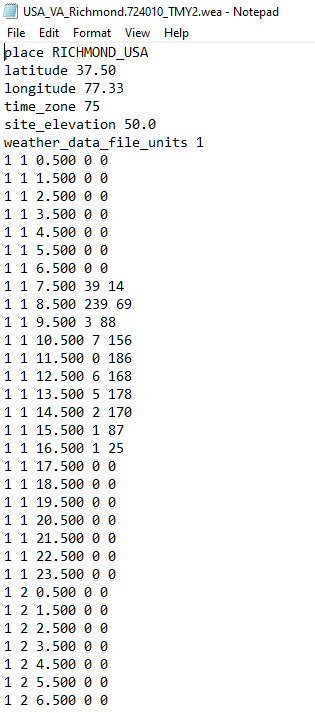

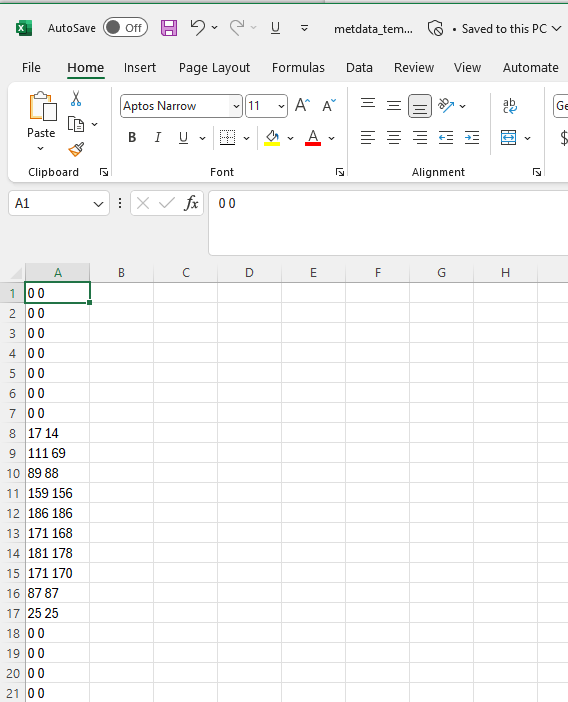

In [7]:
demo.setGround(0.2)
demo.genCumSky() # entire year.

Loading albedo, 1 value(s), 0.200 avg
1 nonzero albedo values.
Loaded  EPWs\metdata_temp.csv
message: Error!  Solar altitude is -7 < -6 degrees and Idh = 13 > 10 W/m^2 on day 76 !Ibn is 0.  Attempting to continue!
Error!  Solar altitude is -7 < -6 degrees and Idh = 11 > 10 W/m^2 on day 78 !Ibn is 0.  Attempting to continue!
Error!  Solar altitude is -6 < -6 degrees and Idh = 14 > 10 W/m^2 on day 81 !Ibn is 0.  Attempting to continue!
There were 4537 sun up hours in this climate file
Total Ibh/Lbh: 0.000000


'skies\\cumulative.rad'

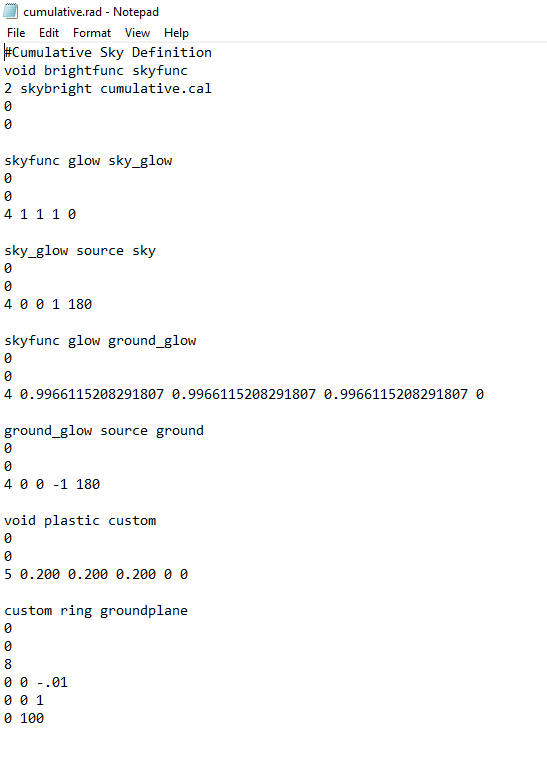


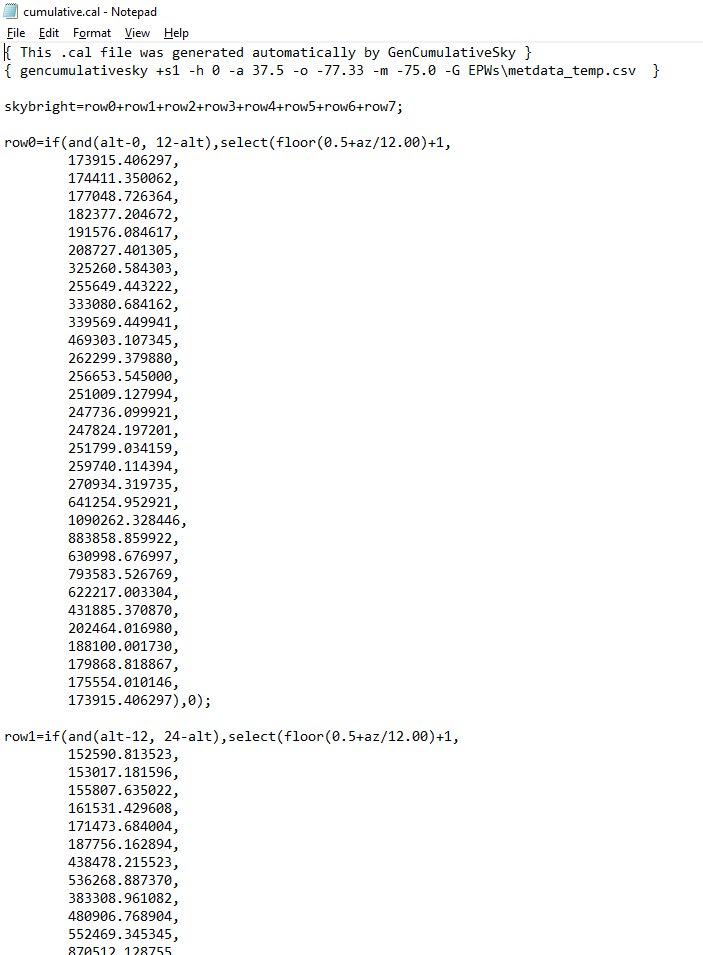

In [8]:
# visible wavelengths only - not what we want...
!gendaymtx -m 1 -A .\EPWs\USA_VA_Richmond.724010_TMY2.wea > .\EPWs\visible_results.mtx

gendaymtx: warning - unusually bright at 17.5 on 1-14
gendaymtx: warning - unusually bright at 17.5 on 1-17
gendaymtx: warning - unusually bright at 17.5 on 1-19
gendaymtx: warning - unusually bright at 17.5 on 1-22
gendaymtx: warning - unusually bright at 17.5 on 1-27
gendaymtx: warning - unusually bright at 17.5 on 1-28
gendaymtx: warning - unusually bright at 17.5 on 1-31
gendaymtx: warning - unusually bright at 17.5 on 2-1
gendaymtx: warning - unusually bright at 17.5 on 2-2
gendaymtx: warning - unusually bright at 6.5 on 3-6
gendaymtx: warning - unusually bright at 6.5 on 3-7
gendaymtx: warning - unusually bright at 18.5 on 3-8
gendaymtx: warning - unusually bright at 6.5 on 3-10
gendaymtx: warning - unusually bright at 6.5 on 3-11
gendaymtx: warning - unusually bright at 18.5 on 3-18
gendaymtx: warning - unusually bright at 18.5 on 3-19
gendaymtx: warning - unusually bright at 18.5 on 3-22
gendaymtx: warning - unusually bright at 18.5 on 3-26
gendaymtx: warning - unusually bright

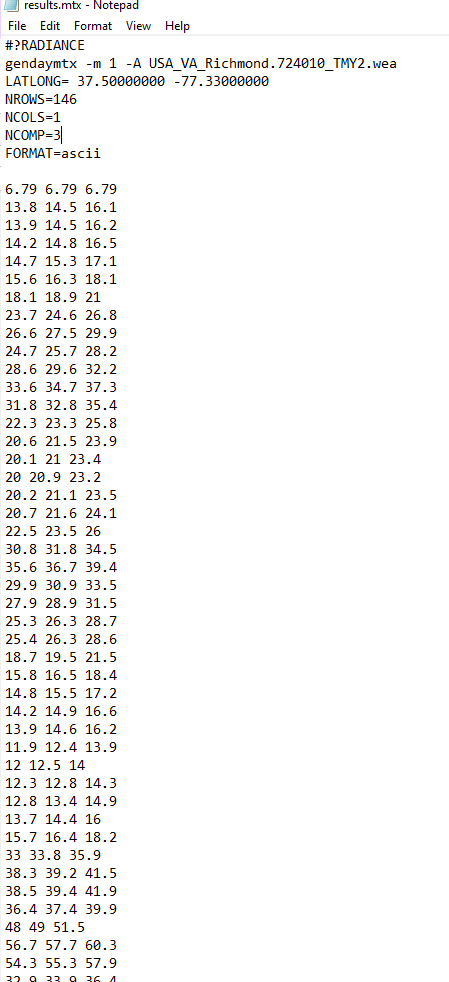

### other tests of gendaymtx

In [9]:
# pyradiance equivalent of: gendaymtx -m 1 -A -O1 ./EPWs/... > ./EPWs/totalirrad_results.mtx
import pyradiance

wea_path = os.path.join('EPWs', 'USA_VA_Richmond.724010_TMY2.wea')
out_path = os.path.join('EPWs', 'totalirrad_results.mtx')

#with open(wea_path, 'rb') as f:
#    wea_bytes = f.read()

mtx_bytes = pyradiance.gendaymtx(weather_data=wea_path, 
                                 mfactor=1, average=True,
                                 solar_radiance=True)  # solar_radiance=True for total irradiance, false for visible only

with open(out_path, 'wb') as f:
    f.write(mtx_bytes)
print(f"Written: {out_path}  ({len(mtx_bytes):,} bytes)")


Written: EPWs\totalirrad_results.mtx  (2,359 bytes)


In [10]:
# total irradiance, not just visible.  This is the correct output
#!gendaymtx -m 1 -A -O1 .\EPWs\USA_VA_Richmond.724010_TMY2.wea > .\EPWs\totalirrad_results.mtx
cmd = "gendaymtx -m 1 -A -O1 ./EPWs/USA_VA_Richmond.724010_TMY2.wea > ./EPWs/totalirrad_results.mtx"
temp_out,err = _popen(cmd,None)
if err is not None:
    if err[0:5] == 'error':
        raise Exception(err[7:])
    #else:
    #    print(err)

In [11]:
# More patches - not directly transferrable to the M=1 .cal files
#!gendaymtx -m 2 -A -O1 .\EPWs\USA_VA_Richmond.724010_TMY2.wea > .\EPWs\totalirrad_results_m2.mtx
cmd = "gendaymtx -m 2 -A -O1 ./EPWs/USA_VA_Richmond.724010_TMY2.wea > ./EPWs/totalirrad_results_m2.mtx"
temp_out,err = _popen(cmd,None)
if err is not None:
    if err[0:5] == 'error':
        raise Exception(err[7:])

In [12]:
# much larger hourly (not cumulative) file.
#!gendaymtx -m 1 .\EPWs\USA_VA_Richmond.724010_TMY2.wea > .\EPWs\I_think_hourly_results.mtx
cmd = "gendaymtx -m 1 ./EPWs/USA_VA_Richmond.724010_TMY2.wea > ./EPWs/I_think_hourly_results.mtx"
temp_out,err = _popen(cmd,None)
if err is not None:
    if err[0:5] == 'error':
        raise Exception(err[7:])

Perhaps we can compare results from gendaylit to this?

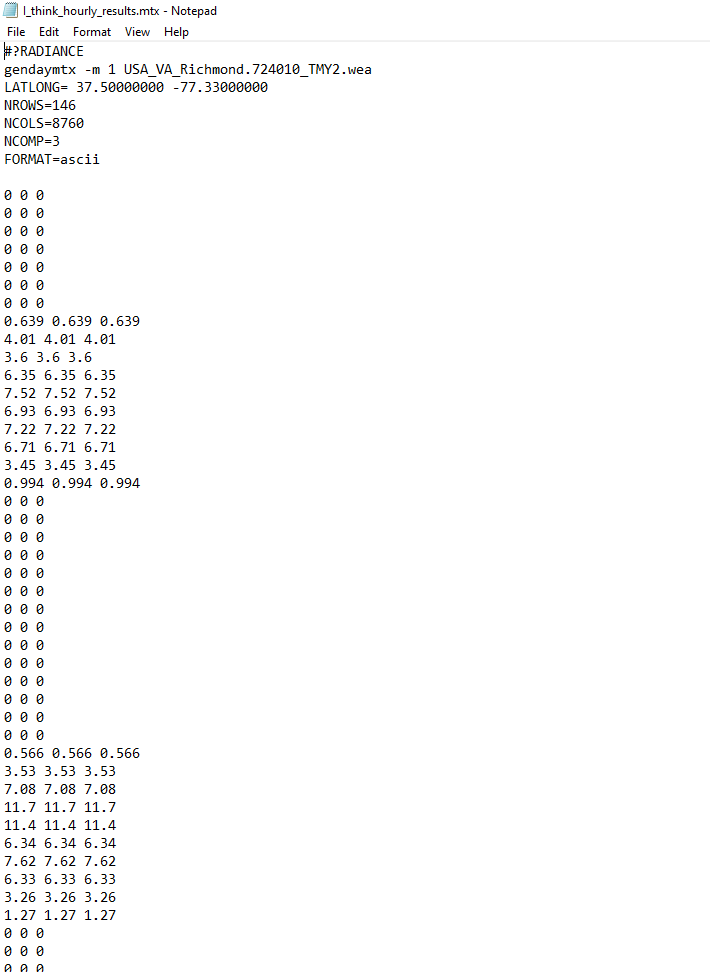

### Initial standard run for comparison

In [13]:
module_type = 'test-module' 
module = demo.makeModule(name=module_type,x=2, y=1)
print(module)



Module Name: test-module
Module test-module updated in module.json
Pre-existing .rad file objects\test-module.rad will be overwritten

<class 'bifacial_radiance.module.ModuleObj'> : {'x': 2, 'y': 1, 'z': 0.02, 'modulematerial': 'black', 'scenex': 2.01, 'sceney': 1.0, 'scenez': 0.1, 'numpanels': 1, 'bifi': 1, 'text': '! genbox black test-module 2 1 0.02 | xform -t -1.0 -0.5 0 -a 1 -t 0 1.0 0', 'modulefile': 'objects\\test-module.rad', 'glass': False, 'glassEdge': 0.01, 'offsetfromaxis': 0, 'xgap': 0.01, 'ygap': 0.0, 'zgap': 0.1}


In [14]:

sceneDict = {'tilt':10,'pitch':3,'clearance_height':0.2,'azimuth':180, 'nMods': 20, 'nRows': 7} 

scene = demo.makeScene(module,sceneDict)


In [15]:
filelist = demo.getfilelist()
filelist

['materials\\ground.rad',
 'skies\\cumulative.rad',
 'objects\\test-module_C_0.20_rtr_3.00_tilt_10_20modsx7rows_origin0,0.rad']

In [16]:
octfile = demo.makeOct(demo.getfilelist())  


Created tutorial_1.oct


In [17]:
analysis = br.AnalysisObj(octfile, demo.basename)


In [18]:
frontscan, backscan = analysis.moduleAnalysis(scene)


In [19]:
results = analysis.analysis(octfile, demo.basename, frontscan, backscan)  


Linescan in process: tutorial_1_Row4_Module10_Front
Linescan in process: tutorial_1_Row4_Module10_Back
Saved: results\irr_tutorial_1_Row4_Module10.csv


In [20]:
print(analysis.Wm2Front)

[1625960. 1625847. 1625751. 1625655. 1625559. 1625463. 1625367. 1625272.
 1625176.]


https://unmethours.com/question/17628/understanding-radiance-the-relationship-between-sky-conditions-and-irradiance/
https://www.radiance-online.org/pipermail/radiance-general/2003-October/001059.html


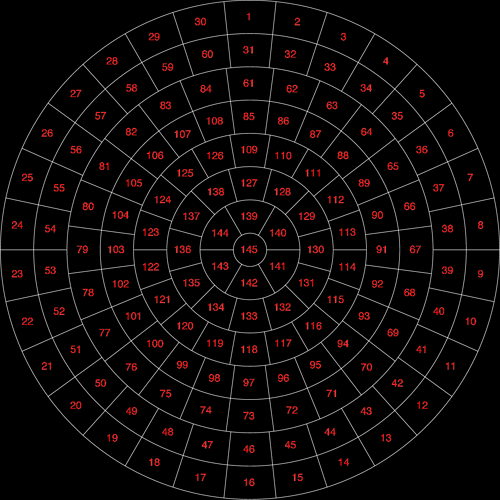

## Claude code analysis of the above comparisons:

## Output File Comparison: `genCumSky()` vs `gendaymtx`

| File | Command | NROWS | NCOLS | Format | Size |
|---|---|---|---|---|---|
| `cumulative.cal` | `genCumSky()` → `gencumulativesky` | 8 altitude bands × azimuth bins | — | Radiance `.cal` function | 3.3 KB |
| `visible_results.mtx` | `gendaymtx -m 1 -A` | 146 patches | 1 (annual) | sky matrix | 2.4 KB |
| `totalirrad_results.mtx` | `gendaymtx -m 1 -A -O1` | 146 patches | 1 (annual) | sky matrix | 2.3 KB |
| `totalirrad_results_m2.mtx` | `gendaymtx -m 2 -A -O1` | 586 patches | 1 (annual) | sky matrix | 8.8 KB |
| `I_think_hourly_results.mtx` | `gendaymtx -m 1` | 146 patches | 8760 (hourly) | sky matrix | 14.8 MB |

### Key Findings

**`totalirrad_results.mtx` is the closest equivalent to `genCumSky()`** because:
- Both are **annual/cumulative** (not hourly)
- Both use the **Tregenza m=1 sky division** (146 patches)
- `-O1` selects **total solar irradiance** (full spectrum), matching what bifacial_radiance needs for energy yield calculations
- `visible_results.mtx` (no `-O1`) uses visible/luminance weighting — **not appropriate** as a drop-in replacement for PV simulation

**`I_think_hourly_results.mtx`** is **not comparable** — `NCOLS=8760` means it stores one sky per hour, not a cumulative sky. It is a completely different data structure used for climate-based daylight modeling with `rfluxmtx`.

**`totalirrad_results_m2.mtx`** has the same total-irradiance/cumulative intent but at higher angular resolution (Reinhart m=2, 586 patches) — compatible for higher-accuracy simulations but not directly interchangeable with the m=1 `.cal` file.

### Format Difference to Resolve

The `cumulative.cal` is a **Radiance function** (used directly in `oconv`/`rpict` rendering), while the `.mtx` files are **sky matrices** used in the two-phase matrix method (`rfluxmtx`). They represent the same physics but in different pipeline formats.

### TODO

- [X] Convert `totalirrad_results.mtx` to a `.rad` sky description (e.g. `cumulative_gendaymtx.rad`) so it can be used as a drop-in replacement for `cumulative.cal` in the existing single-phase Radiance pipeline
- [X] Verify that `oconv` + `rpict`/`rtrace` can consume the converted `.rad` sky and produce equivalent irradiance results to the `genCumSky()` workflow
- [X] Compare numerical results (front/back irradiance from `analysis.analysis()`) between the two sky generation methods on the same scene
- [ ] Evaluate whether the higher-resolution `totalirrad_results_m2.mtx` (Reinhart m=2) offers meaningful accuracy improvement for bifacial simulations
- [ ] Update `bifacial_radiance.genCumSky()` (or add a new method) to call `gendaymtx -m 1 -A -O1` internally once the workflow is validated

---
## TODO #1: Convert `totalirrad_results.mtx` to a Radiance sky description

**Goal:** Generate `skies/cumulative_gendaymtx.cal` and `skies/cumulative_gendaymtx.rad`
so the gendaymtx output can be used as a drop-in replacement for `cumulative.cal` in the
existing single-phase `oconv` → `rtrace` pipeline.

**MTX layout (gendaymtx, Reinhart m=1, NROWS=146):**
- Row 0: ground patch (spectrally flat; equal R=G=B)
- Rows 1–30: altitude band 0–12° (30 azimuth patches)
- Rows 31–60: altitude band 12–24° (30 patches)
- Rows 61–84: altitude band 24–36° (24 patches)
- Rows 85–108: altitude band 36–48° (24 patches)
- Rows 109–126: altitude band 48–60° (18 patches)
- Rows 127–138: altitude band 60–72° (12 patches)
- Rows 139–144: altitude band 72–84° (6 patches)
- Row 145: zenith patch (84–90°, 1 patch)

**Azimuth convention note:** Both gendaymtx and gencumulativesky use the same Radiance
`az` variable (0°=South, increasing Westward). An offset correction may be needed after
comparing results — see TODO #3.

In [ ]:
import numpy as np

def convert_to_annual_whm2(text_data):
    """
    Parses Radiance dctimestep output and returns a NumPy array of annual Wh/m^2.
    """
    annual_wh_m2 = []
    
    for line in text_data.strip().split('\n'):
        parts = line.split()
        
        # Data lines will have exactly 3 components (RGB)
        if len(parts) == 3:
            try:
                r, g, b = [float(x) for x in parts]
                
                # 1. Apply Radiance solar weighting (W/m^2)
                w_m2_avg = (0.265 * r) + (0.670 * g) + (0.065 * b)
                
                # 2. Scale from average W/m^2 to annual Wh/m^2
                annual_wh_m2.append(w_m2_avg * 8760)
            except ValueError:
                # Safely skips header lines that might have 3 words
                continue
                
    return np.array(annual_wh_m2)

# If reading directly from the output file:
# with open('final_results.dat', 'r') as f:
#     results_array = convert_to_annual_whm2(f.read())

In [58]:
import numpy as np

def read_mtx(mtx_file):
    """
    Read a gendaymtx annual cumulative MTX file.
    Returns array of shape (n_patches+1, 3) — one row per patch, columns are R, G, B.
    Row 0 = ground patch; rows 1+ = sky patches (bottom to top).
    Number of sky patches depends on M: M=1 → 145, M=2 → 577, M=4 → 2305.
    """
    with open(mtx_file, 'r') as f:
        lines = f.readlines()
    # Skip header lines until the first blank line
    data_start = next(i + 1 for i, l in enumerate(lines) if l.strip() == '')
    data = [list(map(float, l.split())) for l in lines[data_start:] if l.strip()]
    return np.array(data) * 8760  # Multiply by 8760 to convert from average to total

mtx_path = os.path.join('EPWs', 'totalirrad_results_m2.mtx')
patches = read_mtx(mtx_path)

print(f"Patches shape:          {patches.shape}  (should be (n_sky+1) x 3)")
print(f"Row  0 — ground patch:  {patches[0]}  (expect equal R=G=B)")
print(f"Row  1 — lowest sky:    {patches[1]}")
print(f"Row 30 — end of band 0: {patches[30]}")
print(f"Row 31 — start band 1:  {patches[31]}")
print(f"Row -1 — zenith:        {patches[-1]}")
print(f"\nScalar irradiance range (sky patches only): "
      f"{patches[1:].mean(axis=1).min():.2f} – {patches[1:].mean(axis=1).max():.2f}")


Patches shape:          (578, 3)  (should be (n_sky+1) x 3)
Row  0 — ground patch:  [97236. 97236. 97236.]  (expect equal R=G=B)
Row  1 — lowest sky:    [175200. 183084. 204108.]
Row 30 — end of band 0: [241776. 253164. 282072.]
Row 31 — start band 1:  [241776. 253164. 281196.]
Row -1 — zenith:        [192720. 201480. 224256.]

Scalar irradiance range (sky patches only): 143372.00 – 2076120.00


In [59]:
# Tregenza M=1 base band structure — used as the template for all M values
_TREGENZA_BANDS = [
    ( 0, 12, 30, 12.0),
    (12, 24, 30, 12.0),
    (24, 36, 24, 15.0),
    (36, 48, 24, 15.0),
    (48, 60, 18, 20.0),
    (60, 72, 12, 30.0),
    (72, 84,  6, 60.0),
    (84, 90,  1, 360.0),  # zenith — never subdivided
]

def _make_reinhart_bands(M):
    """
    Build the Reinhart sky band structure for subdivision factor M.

    Each non-zenith Tregenza band is split into M altitude sub-bands, each
    with n_az*M azimuth patches and az_step/M degrees per patch.
    The zenith band (n_az==1) is left as a single patch regardless of M.

    Patch counts: M=1 → 145, M=2 → 577 (= M²×144 + 1), M=4 → 2305.
    """
    bands = []
    for alt_lo, alt_hi, n_az, az_step in _TREGENZA_BANDS:
        if n_az == 1:                    # zenith: keep as a single patch
            bands.append((alt_lo, alt_hi, 1, 360.0))
        else:
            sub_range = (alt_hi - alt_lo) / M
            for i in range(M):
                bands.append((
                    alt_lo + i * sub_range,
                    alt_lo + (i + 1) * sub_range,
                    n_az * M,
                    az_step / M,
                ))
    return bands


def mtx_to_cal(patches, M=1, savefile='cumulative_gendaymtx', sky_path='skies'):
    """
    Convert a gendaymtx annual cumulative MTX into a
    gencumulativesky-compatible .cal file.

    Parameters
    ----------
    patches : np.ndarray, shape (n_sky+1, 3)
        Output of read_mtx(). Row 0 = ground; rows 1+ = sky patches.
    M : int
        Reinhart subdivision factor (1 = Tregenza, 2 = Reinhart M=2, etc.)
        Must match the -m value used with gendaymtx.
    savefile : str
        Base filename (no extension).
    sky_path : str
        Directory for output file.

    Band structure: (alt_lo, alt_hi, n_patches, az_step_deg)
    Patches within each band run counterclockwise from az=0 (South).

    NOTE: azimuth offset vs. gencumulativesky needs empirical verification
    using TODO #3 comparison. Adjust `az_offset_deg` if results diverge.
    """
    bands = _make_reinhart_bands(M)
    n_sky_expected = sum(n for _, _, n, _ in bands)

    sky_irr = patches[1:].mean(axis=1)  # scalar irradiance per sky patch
    if sky_irr.shape[0] != n_sky_expected:
        raise ValueError(
            f"patches has {sky_irr.shape[0]} sky rows but M={M} expects {n_sky_expected}. "
            "Check that the MTX file matches the requested M."
        )

    if sky_path:
        os.makedirs(sky_path, exist_ok=True)
        cal_path = os.path.join(sky_path, savefile + '.cal')
    else:
        cal_path = savefile + '.cal'

    n_bands = len(bands)
    row_sum = '+'.join(f"row{i}" for i in range(n_bands))

    with open(cal_path, 'w') as f:
        f.write(f"{{ Generated from gendaymtx -m {M} -A -O1 }}\n\n")
        f.write(f"skybright={row_sum};\n\n")

        patch_idx = 0
        for row_idx, (alt_lo, alt_hi, n, az_step) in enumerate(bands):
            vals = sky_irr[patch_idx: patch_idx + n]
            patch_idx += n

            if n == 1:  # zenith — no azimuth dependency
                f.write(f"row{row_idx}=if(and(alt-{alt_lo}, {alt_hi}-alt),"
                        f"{vals[0]:.6f},0);\n\n")
            else:
                # Append vals[0] at the end as wrap-around guard.
                # When az is near 360°, select() index reaches n+1; the repeated
                # first value matches the genCumSky convention and avoids a
                # "select(): domain error" from rtrace.
                vals_wrap = list(vals) + [vals[0]]
                vals_str = ',\n        '.join(f"{v:.6f}" for v in vals_wrap)
                f.write(f"row{row_idx}=if(and(alt-{alt_lo}, {alt_hi}-alt),"
                        f"select(floor(0.5+az/{az_step:.2f})+1,\n"
                        f"        {vals_str}),0);\n\n")
        f.write("\n\nalt=asin(Dz)*180/PI;\n\naz=if(azi,azi,azi+360);\nazi=atan2(Dx,Dy)*180/PI;\n")
    print(f"Written: {cal_path}  ({patch_idx} sky patches encoded, M={M})")
    return cal_path

cal_path = mtx_to_cal(patches, M=2, sky_path=os.path.join('skies'))


Written: skies\cumulative_gendaymtx.cal  (577 sky patches encoded, M=2)


In [60]:
def cal_to_rad(cal_path, demo, M=1, savefile='cumulative_gendaymtx'):
    """
    Wrap a .cal file in a Radiance sky .rad description — same template
    as genCumSky() — so it can be passed directly to demo.makeOct().
    """
    sky_path = os.path.dirname(cal_path)

    try:
        groundstring = demo.ground._makeGroundString(cumulativesky=True)
    except Exception as e:
        raise RuntimeError(f"Run demo.setGround() first. Error: {e}")

    skyStr = (
        f"#Cumulative Sky Definition (generated from gendaymtx -m {M} -A -O1)\n"
        "void brightfunc skyfunc\n"
        f"2 skybright {cal_path}\n"
        "0\n"
        "0\n"
        "\nskyfunc glow sky_glow\n"
        "0\n"
        "0\n"
        "4 1 1 1 0\n"
        "\nsky_glow source sky\n"
        "0\n"
        "0\n"
        "4 0 0 1 180\n"
        + groundstring
    )

    rad_path = os.path.join(sky_path, savefile + '.rad')
    with open(rad_path, 'w') as f:
        f.write(skyStr)

    print(f"Written: {rad_path}")
    return rad_path

rad_path = cal_to_rad(cal_path, demo, M=2)
print(f"\nNew sky file ready: {rad_path}")

# Quick sanity check: compare total sky brightness
gendaymtx_total = patches[1:].mean(axis=1).sum()
n_sky = patches.shape[0] - 1
print(f"\nTotal cumulative sky irradiance (gendaymtx, {n_sky} patches): {gendaymtx_total:.1f}")


Written: skies\cumulative_gendaymtx.rad

New sky file ready: skies\cumulative_gendaymtx.rad

Total cumulative sky irradiance (gendaymtx, 577 patches): 266563004.0


---
## TODO #2: Verify `oconv` + `rtrace` with the new gendaymtx sky

Build an octfile using `cumulative_gendaymtx.rad` in place of `cumulative.rad`,
then run the same module analysis used in the original genCumSky workflow.

In [61]:
# Build the filelist using the new gendaymtx-derived sky (mirrors newfilelist2 above)
obj_file = [f for f in demo.getfilelist() if f.endswith('.rad') and 'objects' in f][0]
filelist_gendaymtx = [
    os.path.join('materials', 'ground.rad'),
    rad_path,
    obj_file,
]
print("Filelist for gendaymtx sky:")
for f in filelist_gendaymtx:
    print(f"  {f}")

octfile_new = demo.makeOct(filelist_gendaymtx, octname='tutorial_1_gendaymtx')
print(f"\nCreated octfile: {octfile_new}")

Filelist for gendaymtx sky:
  materials\ground.rad
  skies\cumulative_gendaymtx.rad
  objects\test-module_C_0.20_rtr_3.00_tilt_10_20modsx7rows_origin0,0.rad
Created tutorial_1_gendaymtx.oct

Created octfile: tutorial_1_gendaymtx.oct


In [62]:
# Run the same module analysis with the new sky octfile
analysis_new = br.AnalysisObj(octfile_new, demo.basename + '_gendaymtx')
frontscan_new, backscan_new = analysis_new.moduleAnalysis(scene)
results_new = analysis_new.analysis(
    octfile_new, demo.basename + '_gendaymtx', frontscan_new, backscan_new)

Linescan in process: tutorial_1_gendaymtx_Row4_Module10_Front
Linescan in process: tutorial_1_gendaymtx_Row4_Module10_Back
Saved: results\irr_tutorial_1_gendaymtx_Row4_Module10.csv


In [63]:
print(analysis_new.Wm2Front)
print(analysis_new.Wm2Back)

[1631781. 1631664. 1631566. 1631467. 1631368. 1631270. 1631171. 1631072.
 1635645.]
[146059.8  110519.1   87704.88  71990.53  67017.31  69229.39  75841.53
  90214.62 110144.3 ]


---
## TODO #3: Compare numerical results — `genCumSky()` vs `gendaymtx`

Load the saved CSV results from both simulations and compare front/back irradiance.
A close match (< ~5% difference) validates the pipeline replacement.
Large differences may indicate an azimuth offset or unit scaling issue in the .cal conversion.

In [64]:

front_orig = analysis.Wm2Front.mean()
back_orig  = analysis.Wm2Back.mean()
front_new  = analysis_new.Wm2Front.mean()
back_new   = analysis_new.Wm2Back.mean()

res_orig = pd.DataFrame()
res_orig['Wm2Front'] = analysis.Wm2Front
res_orig['Wm2Back'] = analysis.Wm2Back

res_new = pd.DataFrame()
res_new['Wm2Front'] = analysis_new.Wm2Front
res_new['Wm2Back'] = analysis_new.Wm2Back

print("=" * 55)
print(f"{'':30s} {'genCumSky':>10s} {'gendaymtx':>10s}")
print("=" * 55)
print(f"{'Front irradiance (Wh/m²)':30s} {front_orig:10.2f} {front_new:10.2f}")
print(f"{'Back  irradiance (Wh/m²)':30s} {back_orig:10.2f}  {back_new:10.2f}")
print(f"{'Bifacial ratio':30s} {back_orig/front_orig:10.4f} {back_new/front_new:10.4f}")
print("=" * 55)
print(f"{'Front Δ (Wh/m²)':30s} {front_new - front_orig:+10.2f}")
print(f"{'Back  Δ (Wh/m²)':30s} {back_new  - back_orig:+10.2f}")
print(f"{'Front Δ (%)':30s} {100*(front_new-front_orig)/front_orig:+10.2f}%")
print(f"{'Back  Δ (%)':30s} {100*(back_new -back_orig )/back_orig:+10.2f}%")

                                genCumSky  gendaymtx
Front irradiance (Wh/m²)       1621387.00 1631889.33
Back  irradiance (Wh/m²)         93084.48    92080.16
Bifacial ratio                     0.0574     0.0564
Front Δ (Wh/m²)                 +10502.33
Back  Δ (Wh/m²)                  -1004.32
Front Δ (%)                         +0.65%
Back  Δ (%)                         -1.08%


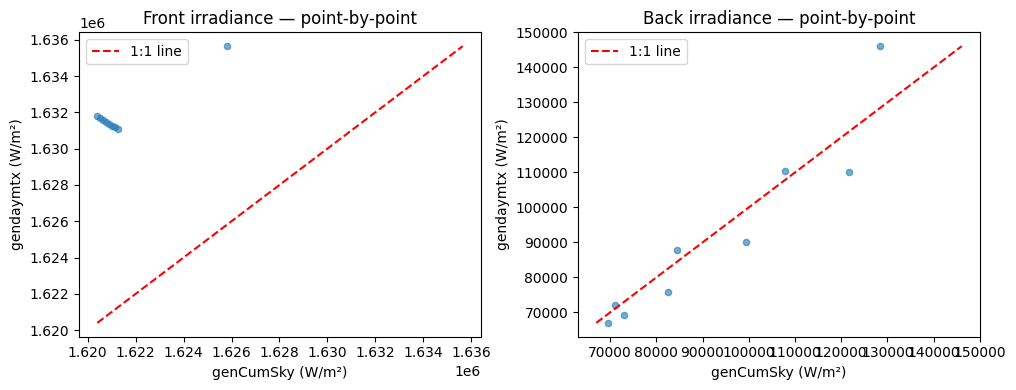

Saved: gencumsky_vs_gendaymtx_comparison.png


In [65]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, col, label in zip(axes, ['Wm2Front', 'Wm2Back'], ['Front', 'Back']):
    ax.scatter(res_orig[col], res_new[col], alpha=0.6, s=20)
    lims = [min(res_orig[col].min(), res_new[col].min()),
            max(res_orig[col].max(), res_new[col].max())]
    ax.plot(lims, lims, 'r--', label='1:1 line')
    ax.set_xlabel('genCumSky (W/m²)')
    ax.set_ylabel('gendaymtx (W/m²)')
    ax.set_title(f'{label} irradiance — point-by-point')
    ax.legend()

plt.tight_layout()
plt.savefig('gencumsky_vs_gendaymtx_comparison.png', dpi=100)
plt.show()
print("Saved: gencumsky_vs_gendaymtx_comparison.png")

## Alternate method - follow rfluxmtx and dctimestep process which apparently is the more updated workflow. Still not working...

In [29]:
## Continue following Example 1 for annual gencumsky simulation.
# online discussion around this: https://discourse.radiance-online.org/t/gencumulativesky-ignore-diffuse-irradiance/996/3
# rfluxmtx introduced, slide 38 onward: https://www.radiance-online.org/community/workshops/2014-london/presentations/day1/Ward_WhatIsNew.pdf
# Tutorial: https://www.radiance-online.org/learning/tutorials/matrix-based-methods


In [30]:
# Greg ward suggestion: 
# gendaymtx will generate a sky vector corresponding to the average W/sr/M^2 of each patch. 
# This is most easily applied in a daylight coefficient calculation, where you’ve used rfluxmtx to calculate the sky-to-point 
# coefficients and dctimestep multiply the matrix against the gendaymtx sky vector output. 
# The alternative is to convert the output to a .dat file and use it with a colordata (or brightdata) 
# primitive with tregenza.cal or similar, but this is a bit less standard. In the end, you should get similar results from 
# rfluxmtx that you would from rtrace.
# In either case, you would multiply the final result by 8760/1000 to get KWh/m^2/year, 
# assuming the -I+ option was used and your weather file contains evenly-spaced values.

In [85]:
# Gemini details continue: create receiver.rad file
def make_receiver(filename):
    """
    Create a static `.rad` file to act as the receiver for `rfluxmtx`. 
    This file defines the actual geometry of the sky dome so the rays have something to hit.
    """
    with open(filename, 'w') as f:
        f.write("#@rfluxmtx h=r1 u=Y\n")
        f.write("void glow sky_glow\n0\n0\n4 1 1 1 0\n")
        f.write("sky_glow source sky\n0\n0\n4 0 0 1 180\n")
        f.write("#@rfluxmtx h=u\n")
        f.write("void glow ground_glow\n0\n0\n4 1 1 1 0\n")
        f.write("ground_glow source ground\n0\n0\n4 0 0 -1 180\n")
    return filename  

receiver = make_receiver(os.path.join('objects', 'receiver.rad'))


In [86]:
filelist_nosky = demo.getfilelist()
# create groundplane
with open('objects/groundplane.rad','w') as f:
    f.write('void plastic custom\n0\n0\n5 0.200 0.200 0.200 0 0\n\ncustom ring groundplane\n0\n0\n8\n0 0 -.01\n0 0 1\n0 100')
filelist_nosky = [ filelist_nosky[0], 'objects/groundplane.rad', filelist_nosky[2]]
print(filelist_nosky)
octfile_nosky = demo.makeOct(filelist_nosky, octname='tutorial_1_nosky') 

['materials\\ground.rad', 'objects/groundplane.rad', 'objects\\test-module_C_0.20_rtr_3.00_tilt_10_20modsx7rows_origin0,0.rad']
Created tutorial_1_nosky.oct


In [87]:
# Then, run `rfluxmtx` to calculate how much of each sky patch is visible from your sensors, 
# taking into account the shading and reflections of your scene.
# cat sensors.txt | rfluxmtx -ab 4 -ad 1000 - receiver.rad -i scene.oct > daylight_coefficients.mtx

linepts = analysis._linePtsMakeDict(frontscan)
#print(linepts)
# convert linepts to scan with rtrace:
cmd = "rtrace -h -opn tutorial_1_nosky.oct"
surface_points,err = _popen(cmd,linepts.encode())
if err is not None: print(err)

# next command makes use of existing octree
cmd = "rfluxmtx -I+ -ab 5 -ad 2048 - objects/receiver.rad -i tutorial_1_nosky.oct > daylight_coefficients.mtx"
# build fresh octree. Note this recompiles the octree each time, taking extra memory if its run multiple times.
# note: If you have a large number of .rad files, you don't need to type them all out manually. use e.g.
# rfluxmtx -ab 4 -ad 1000 - receiver.rad materials/*.mat objects/*.rad
#cmd = "rfluxmtx -ab 5 -ad 2048 - objects/receiver.rad materials/ground.rad objects/test-module_C_0.20_rtr_3.00_tilt_10_20modsx7rows_origin0,0.rad > daylight_coefficients.mtx"

temp_out,err = _popen(cmd,surface_points.encode())
if err is not None:
    if err[0:5] == 'error':
        raise Exception(err[7:])
    else:
        print(err)

message: rtrace: warning - no light sources found


In [88]:
# Now use `dctimestep` to multiply the geometric matrix ($\mathbf{D}$) by the annual sky matrix ($\mathbf{S}$).
# dctimestep daylight_coefficients.mtx annual_sky.smx > final_results.dat
cmd = "dctimestep daylight_coefficients.mtx EPWs/totalirrad_results.mtx"
text_data,err = _popen(cmd,None)
if err is not None:
    if err[0:5] == 'error':
        raise Exception(err[7:])
    else:
        print(err)

In [89]:
annual_front = convert_to_annual_whm2(text_data)
print(annual_front)  #good match...

[1598752.77462 1614368.03088 1615896.94872 1608644.89074 1618031.70378
 1618529.56962 1611757.13478 1618077.79014 1607601.83754]


In [90]:
linepts = analysis._linePtsMakeDict(backscan)
#print(linepts)
# convert linepts to scan with rtrace:
cmd = "rtrace -h -opn tutorial_1_nosky.oct"
surface_points,err = _popen(cmd,linepts.encode())
if err is not None: print(err)

# next command makes use of existing octree
cmd = "rfluxmtx -I+ -ab 5 -ad 2048 - objects/receiver.rad -i tutorial_1_nosky.oct > daylight_coefficients.mtx"
# build fresh octree. Note this recompiles the octree each time, taking extra memory if its run multiple times.
# note: If you have a large number of .rad files, you don't need to type them all out manually. use e.g.
# rfluxmtx -ab 4 -ad 1000 - receiver.rad materials/*.mat objects/*.rad
#cmd = "rfluxmtx -ab 5 -ad 2048 - objects/receiver.rad materials/ground.rad objects/test-module_C_0.20_rtr_3.00_tilt_10_20modsx7rows_origin0,0.rad > daylight_coefficients.mtx"

temp_out,err = _popen(cmd,surface_points.encode())
if err is not None: print(err)

cmd = "dctimestep daylight_coefficients.mtx EPWs/totalirrad_results.mtx"
text_data,err = _popen(cmd,None)
if err is not None: print(err)

annual_back = convert_to_annual_whm2(text_data)
print(annual_back)  #good match...

message: rtrace: warning - no light sources found
[134395.990518  106472.579478   86057.5508946  83767.9255608
  69762.1644678  74559.0509406  84172.2190956  86742.5429052
 107252.416578 ]


In [91]:

res_annual = pd.DataFrame()
res_annual['Wm2Front'] = annual_front
res_annual['Wm2Back'] = annual_back

print("=" * 75)
print(f"{'':30s} {'genCumSky':>10s} {'gendaymtx':>10s} {'rfluxmtx':>10s}")
print("=" * 75)
print(f"{'Front irradiance (Wh/m²)':30s} {front_orig:10.2f} {front_new:10.2f} {np.mean(annual_front):10.2f}")
print(f"{'Back  irradiance (Wh/m²)':30s} {back_orig:10.2f}  {back_new:10.2f} {np.mean(annual_back):10.2f}")
print(f"{'Bifacial ratio':30s} {back_orig/front_orig:10.4f} {back_new/front_new:10.4f} {np.mean(annual_back)/np.mean(annual_front):10.4f}")
print("=" * 75)
print(f"{'Front Δ (Wh/m²)':30s} {front_new - front_orig:+10.2f}")
print(f"{'Back  Δ (Wh/m²)':30s} {back_new  - back_orig:+10.2f}")
print(f"{'Front Δ (%)':30s} {100*(front_new-front_orig)/front_orig:+10.2f}%  {100*(np.mean(annual_front)-front_orig)/front_orig:+10.2f}%")
print(f"{'Back  Δ (%)':30s} {100*(back_new -back_orig )/back_orig:+10.2f}%  {100*(np.mean(annual_back) -back_orig )/back_orig:+10.2f}%")

                                genCumSky  gendaymtx   rfluxmtx
Front irradiance (Wh/m²)       1621387.00 1631889.33 1612406.74
Back  irradiance (Wh/m²)         93084.48    92080.16   92575.83
Bifacial ratio                     0.0574     0.0564     0.0574
Front Δ (Wh/m²)                 +10502.33
Back  Δ (Wh/m²)                  -1004.32
Front Δ (%)                         +0.65%       -0.55%
Back  Δ (%)                         -1.08%       -0.55%


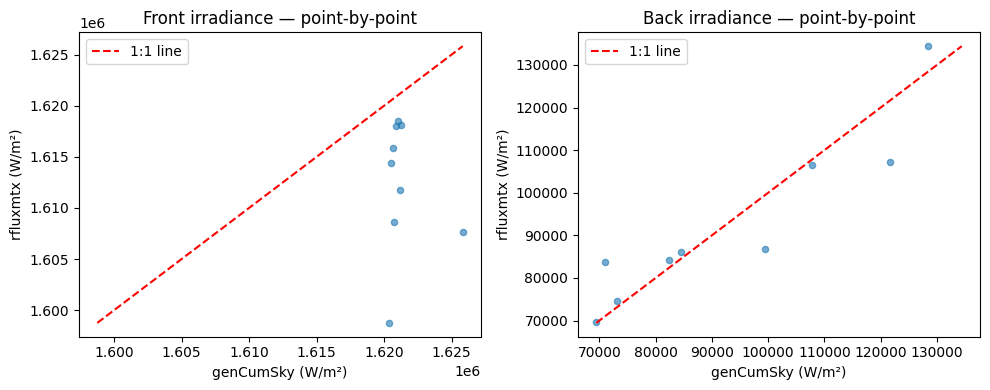

Saved: gencumsky_vs_rfluxmtx_comparison.png


In [92]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, col, label in zip(axes, ['Wm2Front', 'Wm2Back'], ['Front', 'Back']):
    ax.scatter(res_orig[col], res_annual[col], alpha=0.6, s=20)
    lims = [min(res_orig[col].min(), res_annual[col].min()),
            max(res_orig[col].max(), res_annual[col].max())]
    ax.plot(lims, lims, 'r--', label='1:1 line')
    ax.set_xlabel('genCumSky (W/m²)')
    ax.set_ylabel('rfluxmtx (W/m²)')
    ax.set_title(f'{label} irradiance — point-by-point')
    ax.legend()

plt.tight_layout()
plt.savefig('gencumsky_vs_rfluxmtx_comparison.png', dpi=100)
plt.show()
print("Saved: gencumsky_vs_rfluxmtx_comparison.png")